## Bank Customer Churn Prediction

**This project aims to predict whether a bank customer will leave the bank (churn) based on customer information such as age, balance, credit score, activity level, and salary.**

**The project includes:**
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Handling imbalanced data using SMOTE
- Random Forest and XGBoost models
- Feature importance analysis

**Import Libraries**

In [92]:
#impot libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 


**Load the Dataset**

In [93]:
# Load the Dataset
df = pd.read_csv("Bank Customer Churn Prediction.csv")

In [94]:
# inspect  the first 5 row 
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [95]:
df.tail()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,15628319,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


**Data Understanding**

In [127]:
#Understand the structure of the dataset, check the number of rows and columns, inspect data types, and identify the target variable.
df.shape



(10000, 12)

In [97]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [99]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Observation:

The dataset contains customer information such as credit score, age, balance, and activity status.  
The target column is `churn`, where:
- `0` = customer stays
- `1` = customer leaves the bank

The dataset is imbalanced because the number of customers who stay is much higher than the number of customers who churn.


In [128]:
df['churn'].value_counts()
df['churn'].value_counts(normalize=True)*100

churn
0    79.63
1    20.37
Name: proportion, dtype: float64

In [102]:
#check the missing values
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [103]:
# Remove unnecessary columns
df = df.drop(['customer_id'], axis = 1)

In [104]:
df = pd.get_dummies(df, drop_first=True)

In [105]:
df.head()


,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


**Exploratory Data Analysis**

**EDA helps us understand the relationship between customer characteristics and churn.**

In [106]:
x = df.drop(['churn'],axis = 1)
y = df['churn']

**Churn Distribution**

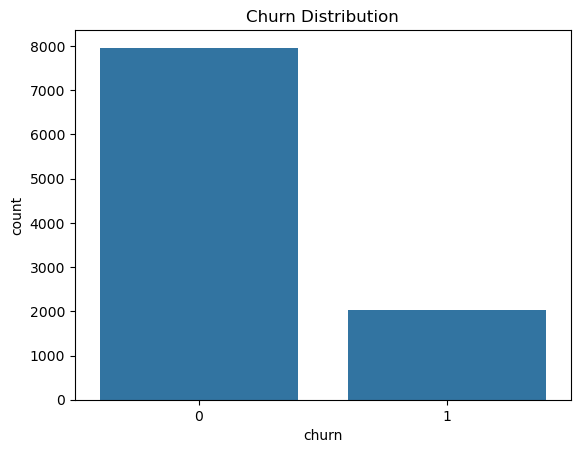

In [107]:
sns.countplot(x='churn', data=df)
plt.title('Churn Distribution')
plt.show()

### Insight: Churn Distribution

Most customers do not leave the bank. The dataset contains significantly fewer churned customers, which may affect model performance.

**Age vs Churn**

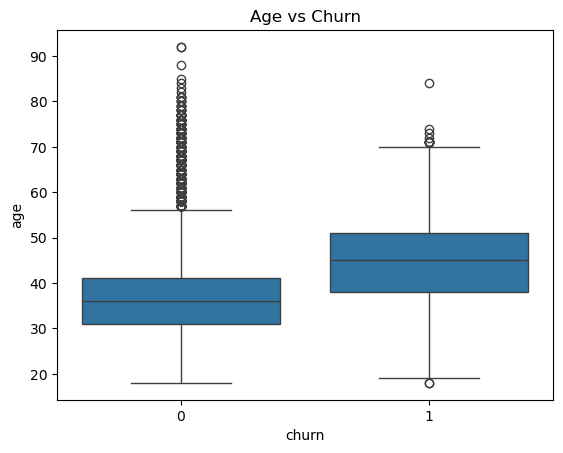

In [108]:
sns.boxplot(x='churn', y='age', data=df)
plt.title('Age vs Churn')
plt.show()

### Insight: Age vs Churn

Customers who churn tend to be older than customers who stay. Age appears to be an important factor in predicting churn.

**Balance vs Churn**

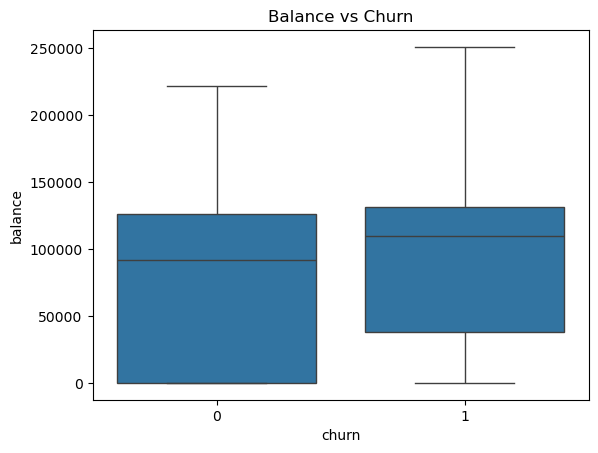

In [109]:
sns.boxplot(x='churn', y='balance', data=df)
plt.title('Balance vs Churn')
plt.show()

### Insight: Balance vs Churn

Customers with higher account balances appear more likely to churn.

**Country vs Churn**

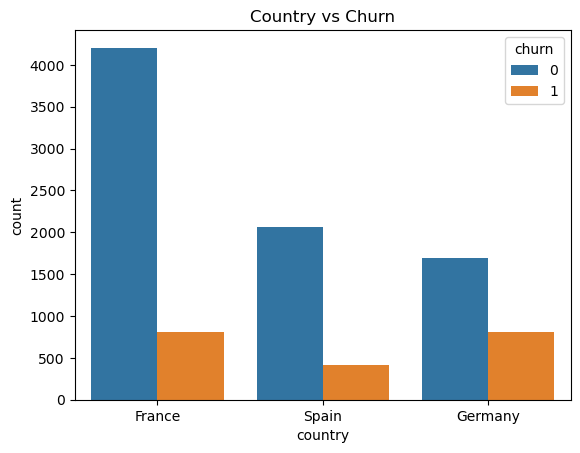

In [110]:
original_df = pd.read_csv('Bank Customer Churn Prediction.csv')
original_df = original_df.drop('customer_id', axis=1)
df = original_df.copy()
df = pd.get_dummies(df, drop_first=True)
sns.countplot(x='country', hue='churn', data=original_df)
plt.title('Country vs Churn')
plt.show()

### Insight: Country vs Churn

Customers from Germany show a higher churn rate compared to customers from France and Spain.

**Active Member vs Churn**

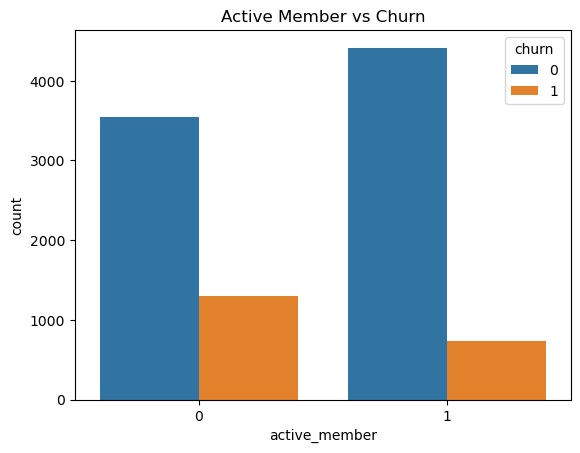

In [111]:
sns.countplot(x='active_member', hue='churn', data=original_df)
plt.title('Active Member vs Churn')
plt.show()

### Insight: Active Member vs Churn

Inactive customers are more likely to leave the bank, while active members are more likely to stay.

**Correlation Heatmap**

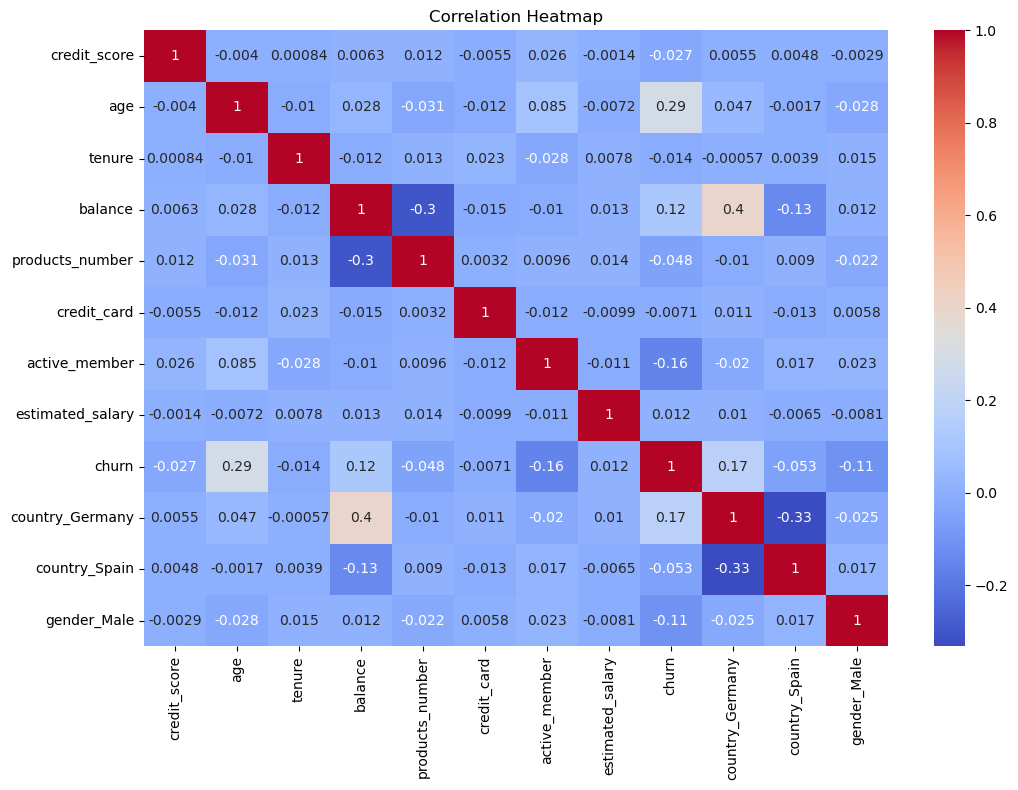

In [112]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Insight: Correlation Heatmap

Age, balance, and activity status show noticeable relationships with churn. However, no single feature alone is strongly correlated, so machine learning models are useful.

**Data Preprocessing & Train-Test Split**

Before training the model, unnecessary columns were removed and categorical variables were converted into numerical values.

The dataset was divided into training and testing sets.  
80% of the data was used for training and 20% for testing.

`stratify=y` was used to preserve the same churn distribution in both training and testing datasets.

In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Baseline Model - Random Forest**

In [114]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state =42)
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
y_pred = model.predict(X_test)
print(y_pred)
print(y_pred[:10])


[0 0 0 ... 1 0 0]
[0 0 0 0 0 0 0 0 0 0]


In [116]:
print("Actual:", y_test[:10].values)
print("Predicted:", y_pred[:10])

Actual: [0 0 0 0 0 0 0 0 0 0]
Predicted: [0 0 0 0 0 0 0 0 0 0]


In [117]:
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})

print(comparison)

   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0


In [118]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
print("confusion_matrixs",confusion_matrix(y_test,y_pred))
print("Classification",classification_report(y_test,y_pred))
print("Accuracy",accuracy_score(y_test,y_pred))


confusion_matrixs [[1541   52]
 [ 219  188]]
Classification               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000

Accuracy 0.8645


### Observation

The Random Forest model achieved high overall accuracy, but it struggled to identify churned customers.

- Accuracy: 86.45%
- Recall for churned customers: 46%

This means the model missed many customers who were likely to leave.

**Handling Imbalanced Data with SMOTE**

In [119]:
pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


**Because the dataset is imbalanced, SMOTE was used to create additional examples of churned customers in the training data.**

In [120]:
#Handling Imbalanced Data with SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

churn
0    6370
1    1630
Name: count, dtype: int64
churn
1    6370
0    6370
Name: count, dtype: int64


In [121]:
model_smote = RandomForestClassifier(random_state=42)

model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)

In [122]:
print(y_pred_smote)

[0 0 0 ... 1 0 0]


In [123]:
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))
print("Accuracy:", accuracy_score(y_test, y_pred_smote))

[[1384  209]
 [ 152  255]]
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      1593
           1       0.55      0.63      0.59       407

    accuracy                           0.82      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.83      0.82      0.82      2000

Accuracy: 0.8195


### Observation

After applying SMOTE, the model became much better at identifying churned customers.

- Accuracy: 81.95%
- Recall for churned customers increased from 46% to 63%

Although the overall accuracy decreased slightly, the model became more useful for business purposes because it detected more churned customers.

**XGBoost Model**

In [124]:
!pip install xgboost

In [125]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)

xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

[[1377  216]
 [ 150  257]]
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      1593
           1       0.54      0.63      0.58       407

    accuracy                           0.82      2000
   macro avg       0.72      0.75      0.73      2000
weighted avg       0.83      0.82      0.82      2000

Accuracy: 0.817


### Observation

The XGBoost model produced similar performance to Random Forest + SMOTE.

- Accuracy: 81.7%
- Recall for churned customers: 63%

Random Forest + SMOTE remained the best model because it achieved slightly better accuracy and precision.

**Feature Importance**

In [126]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_smote.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

            Feature  Importance
1               age    0.219257
3           balance    0.132949
7  estimated_salary    0.124561
6     active_member    0.110488
0      credit_score    0.108834
4   products_number    0.108173
2            tenure    0.070705
8   country_Germany    0.066624
5       credit_card    0.021256
9     country_Spain    0.020509


### Observation

The most important features influencing churn are:

1. Age
2. Balance
3. Estimated Salary
4. Active Member
5. Credit Score

These features have the strongest impact on whether a customer leaves the bank.

## Conclusion:

In this project, I developed a bank customer churn prediction model using Random Forest and XGBoost.

Because the dataset was imbalanced, I applied SMOTE to improve the model’s ability to detect churned customers.

### Final Results
- Baseline Random Forest Accuracy: 86.45%
- Random Forest + SMOTE Accuracy: 81.95%
- Churn Recall improved from 46% to 63%

### Important Factors Influencing Churn
- Age
- Balance
- Estimated Salary
- Active Member
- Credit Score

This project demonstrates how machine learning can help banks identify customers who are likely to leave and take preventive action.